<a href="https://colab.research.google.com/github/Ridhof177/Tugas-Mata-Kuliah-Teknik-Pengambilan-Sampel-dan-Data-Wrangling./blob/main/TUGAS_PRAKTIKUM_2_RIDHO_FATILLA_WIBAWA_SAINS_DATA_24_PEMODELAN_SIMULASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul Praktikum
## Analisis Regresi Linier, Regresi Linier Berganda, dan Evaluasi Model (MAE, MSE, RMSE)



## Import Library

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Membaca Dataset

Dataset yang digunakan misalnya dataset harga rumah.

In [53]:
data = pd.read_csv('/content/1D_Porosity.csv')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


## Informasi Dataset

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


## Statistik Deskriptif

In [55]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


## Visualisasi Hubungan Variabel

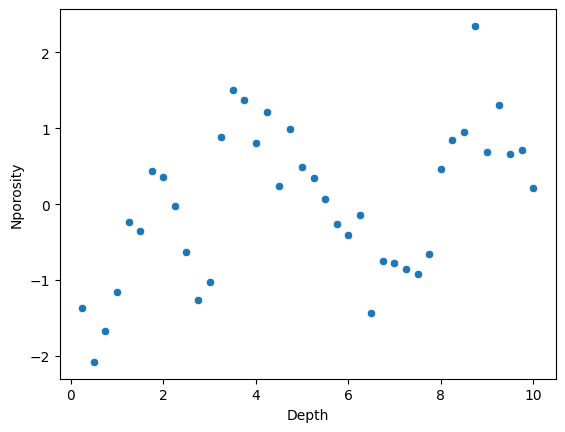

In [56]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

Scatter plot menunjukkan hubungan antara Depth dan Nporosity. Titik-titik data tidak membentuk garis lurus sempurna, tetapi cenderung membentuk pola naik dan turun. Hal ini menunjukkan bahwa hubungan antara kedua variabel tidak sepenuhnya linear. Oleh karena itu, selain regresi linear sederhana, regresi polynomial dapat digunakan untuk menangkap pola data dengan lebih baik.

# Regresi Linier Sederhana

Model regresi:

Y = β0 + β1X + ε

## Menentukan Variabel

In [57]:
X = data[['Depth']]
y = data['Nporosity']

## Membuat Model Regresi

In [58]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Melihat Koefisien Model

In [59]:
print('Intercept:', model.intercept_)
print('Koefisien:', model.coef_)

Intercept: -0.6919615384615387
Koefisien: [0.13935835]


Hasil regresi menunjukkan nilai intercept sebesar -0.6919 dan koefisien sebesar 0.1393. Berdasarkan nilai tersebut, model regresi linear sederhana yang terbentuk adalah:

**Nporosity = -0.6919 + 0.1393 × Depth**

Nilai koefisien sebesar 0.1393 menunjukkan bahwa setiap kenaikan Depth sebesar 1 unit akan menyebabkan Nporosity meningkat sekitar 0.1393 unit. Hal ini menunjukkan adanya hubungan positif antara variabel Depth dan Nporosity.

Sedangkan nilai intercept -0.6919 menunjukkan nilai perkiraan Nporosity ketika Depth bernilai 0. Dengan demikian, model regresi ini dapat digunakan untuk memperkirakan nilai Nporosity berdasarkan perubahan nilai Depth.

##Membuat Visualisasi Model

## Prediksi

In [60]:
y_pred = model.predict(X)
print(y_pred)

[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


## Mean Absolute Error (MAE) , MEan Squared Error (MSE) dan Root Mean Square Error (RMSE)

In [61]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))


print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7399434333958724
MSE: 0.7979390086772984
RMSE: 0.8932743188278158


Hasil evaluasi model regresi menunjukkan nilai MAE = 0.7399, MSE = 0.7979, dan RMSE = 0.8933. Nilai MAE (Mean Absolute Error) sebesar 0.7399 menunjukkan bahwa rata-rata selisih absolut antara nilai Nporosity sebenarnya dengan nilai prediksi model adalah sekitar 0.7399.

Nilai MSE (Mean Squared Error) sebesar 0.7979 merupakan rata-rata dari kuadrat selisih antara nilai aktual dan nilai prediksi. Karena error dikuadratkan, MSE memberikan penalti lebih besar terhadap kesalahan yang besar.

Sedangkan RMSE (Root Mean Squared Error) sebesar 0.8933 merupakan akar dari MSE dan menunjukkan besar kesalahan prediksi model dalam satuan yang sama dengan data Nporosity. Nilai RMSE ini menunjukkan bahwa rata-rata kesalahan prediksi model terhadap data sebenarnya sekitar 0.8933.

Semakin kecil nilai MAE, MSE, dan RMSE, maka semakin baik kemampuan model dalam memprediksi data.

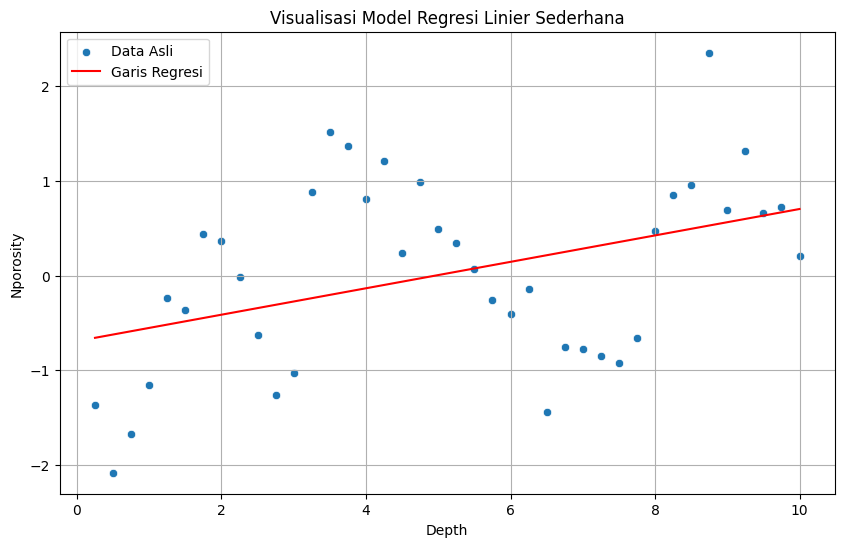

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

Scatter plot di atas menunjukkan hubungan antara Depth dan Nporosity. Titik biru merepresentasikan data asli, sedangkan garis merah menunjukkan garis regresi linear yang dihasilkan oleh model. Garis regresi memiliki kecenderungan meningkat, yang berarti ketika nilai Depth bertambah, nilai Nporosity cenderung meningkat.

Namun, terlihat bahwa beberapa titik data berada cukup jauh dari garis regresi. Hal ini menunjukkan bahwa model regresi linear belum sepenuhnya mampu mengikuti pola data dengan baik. Jarak antara titik data dengan garis regresi inilah yang menyebabkan munculnya nilai error pada model.

Hal ini terlihat dari nilai evaluasi model yaitu MAE sebesar 0.7399, MSE sebesar 0.7979, dan RMSE sebesar 0.8933. Nilai-nilai tersebut menunjukkan rata-rata kesalahan antara nilai prediksi model dan nilai data sebenarnya. Semakin jauh titik data dari garis regresi, maka nilai MAE, MSE, dan RMSE akan semakin besar. Oleh karena itu, model regresi linear pada data ini masih memiliki tingkat kesalahan yang cukup besar dalam memprediksi nilai Nporosity.

# Regresi Polynomial

Regresi polynomial merupakan pengembangan dari regresi linier yang digunakan untuk memodelkan hubungan nonlinier antara variabel independen dan variabel dependen. Jika hubungan antara variabel tidak dapat dijelaskan dengan garis lurus, maka regresi polynomial dapat digunakan dengan menambahkan pangkat dari variabel independen ke dalam model.

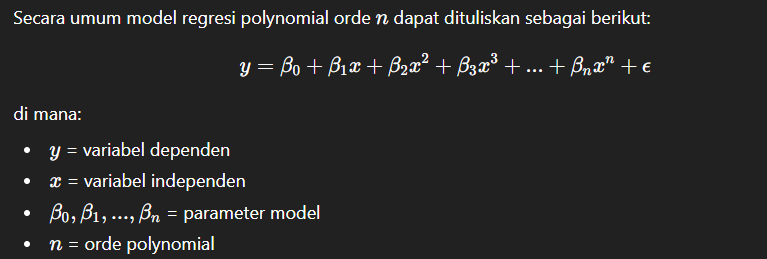


## Membuat model orde 2

In [63]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562

In [64]:
#Membuat model orde 2
model2 = LinearRegression()

model2.fit(X_poly, y)

LinearRegression()

## Prediksi

In [65]:
y_pred2 = model2.predict(X_poly2)

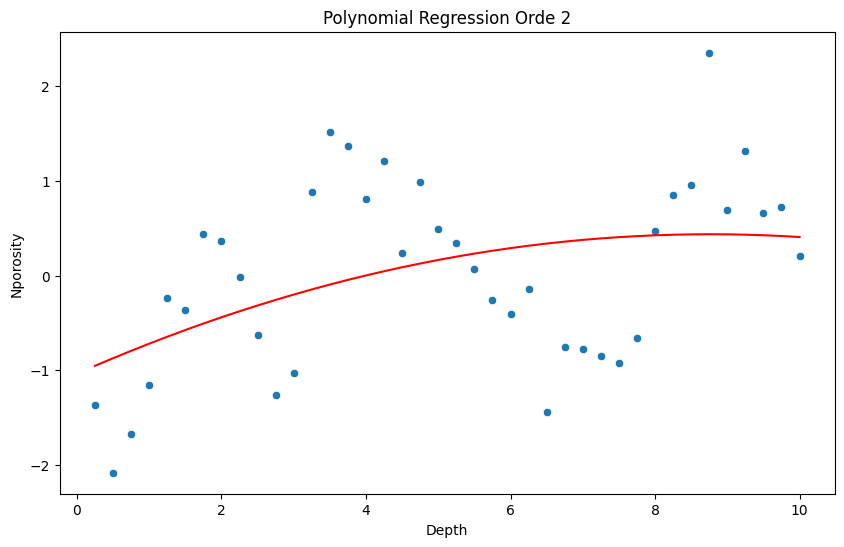

In [66]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Depth', y='Nporosity', data=data)

plt.plot(X, y_pred2, color='red')

plt.title('Polynomial Regression Orde 2')
plt.xlabel('Depth')
plt.ylabel('Nporosity')

plt.show()

Grafik di atas menunjukkan hasil regresi polynomial orde 2 antara Depth dan Nporosity. Titik-titik pada grafik merupakan data asli, sedangkan garis merah menunjukkan kurva regresi polynomial yang dihasilkan oleh model.

Berbeda dengan regresi linear yang menghasilkan garis lurus, regresi polynomial orde 2 menghasilkan kurva melengkung (parabola). Kurva ini dapat mengikuti pola data dengan lebih baik karena mempertimbangkan pengaruh Depth² selain Depth. Dari grafik terlihat bahwa model mampu menangkap perubahan pola hubungan antara Depth dan Nporosity, dimana nilai Nporosity meningkat pada kedalaman tertentu sebelum kemudian cenderung stabil.

Dengan demikian, regresi polynomial orde 2 dapat memodelkan hubungan non-linear antara Depth dan Nporosity dengan lebih baik dibandingkan regresi linear sederhana.

## Membuat model orde 3

In [67]:
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)
X_poly3

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01],
       [1.00000000e+00, 2.75000000e+00, 7.56250000e+00, 2.07968750e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01],
       [1.00000000e+00, 3.25000000e+00, 1.05625000e+01, 3.43281250e+01],
       [1.00000000e+00, 3.50000000e+00, 1.22500000e

In [68]:
#Membuat model orde 2
model3 = LinearRegression()
model3.fit(X_poly3, y)

LinearRegression()

## Prediksi

In [69]:
y_pred3 = model3.predict(X_poly3)

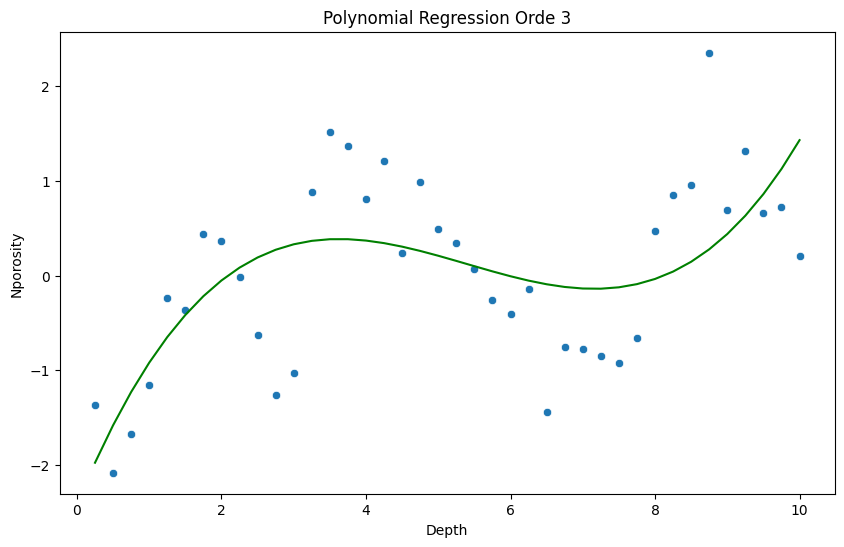

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Depth', y='Nporosity', data=data)

plt.plot(X, y_pred3, color='green')

plt.title('Polynomial Regression Orde 3')
plt.xlabel('Depth')
plt.ylabel('Nporosity')

plt.show()

Grafik di atas menunjukkan hasil regresi polynomial orde 3 antara Depth dan Nporosity. Titik-titik pada grafik merupakan data asli, sedangkan garis hijau menunjukkan kurva regresi polynomial orde 3 yang dihasilkan oleh model.

Kurva pada regresi polynomial orde 3 terlihat lebih fleksibel dibandingkan regresi linear maupun polynomial orde 2. Hal ini karena model mempertimbangkan tambahan fitur Depth³, sehingga mampu menangkap perubahan pola hubungan yang lebih kompleks antara Depth dan Nporosity. Dari grafik terlihat bahwa kurva dapat mengikuti pola naik dan turun pada data dengan lebih baik.

Dengan demikian, regresi polynomial orde 3 dapat memodelkan hubungan non-linear antara Depth dan Nporosity dengan lebih baik dibandingkan model dengan orde yang lebih rendah.

## Membuat model orde 4

In [71]:
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)
X_poly4

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01,
        3.90625000e+01],
       [1.00000000e+00, 2.7500

In [72]:
#Membuat model orde 2
model4 = LinearRegression()
model4.fit(X_poly4, y)

LinearRegression()

## Prediksi

In [73]:
y_pred4 = model4.predict(X_poly4)

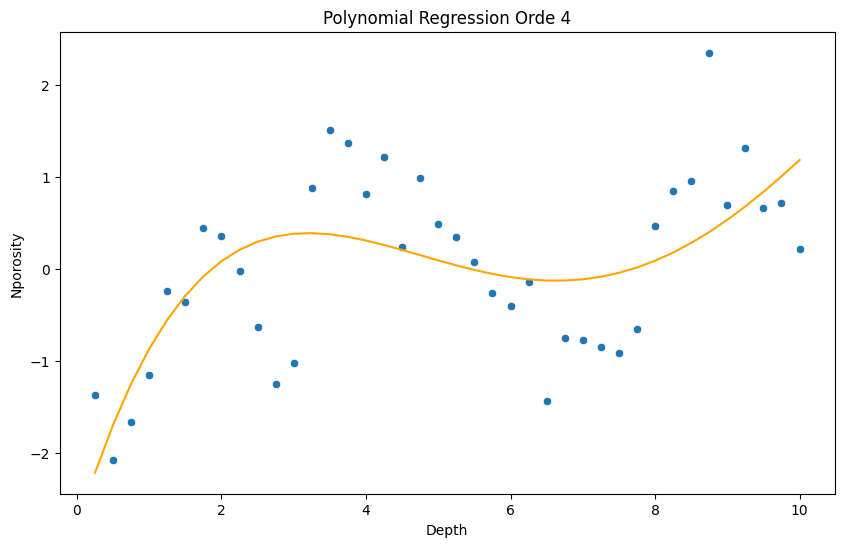

In [74]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Depth', y='Nporosity', data=data)

plt.plot(X, y_pred4, color='orange')

plt.title('Polynomial Regression Orde 4')
plt.xlabel('Depth')
plt.ylabel('Nporosity')

plt.show()

Grafik di atas menunjukkan hasil regresi polynomial orde 4 antara Depth dan Nporosity. Titik-titik pada grafik merupakan data asli, sedangkan garis oranye menunjukkan kurva regresi polynomial orde 4 yang dihasilkan oleh model.

Kurva pada regresi polynomial orde 4 terlihat lebih fleksibel dibandingkan model orde sebelumnya karena model mempertimbangkan tambahan fitur hingga Depth⁴. Hal ini memungkinkan model menangkap pola hubungan yang lebih kompleks antara Depth dan Nporosity, sehingga kurva dapat mengikuti perubahan pola data dengan lebih baik.

Namun, semakin tinggi orde polynomial yang digunakan, model menjadi semakin kompleks. Jika orde terlalu tinggi, model berpotensi mengalami overfitting, yaitu model terlalu menyesuaikan diri dengan data yang ada sehingga kurang baik dalam melakukan prediksi pada data baru.

## Membuat model orde 5

In [75]:
poly5 = PolynomialFeatures(degree=5)
X_poly5 = poly5.fit_transform(X)

In [76]:
#Membuat model orde 2
model5 = LinearRegression()
model5.fit(X_poly5, y)

LinearRegression()

## Prediksi

In [77]:
y_pred5 = model5.predict(X_poly5)

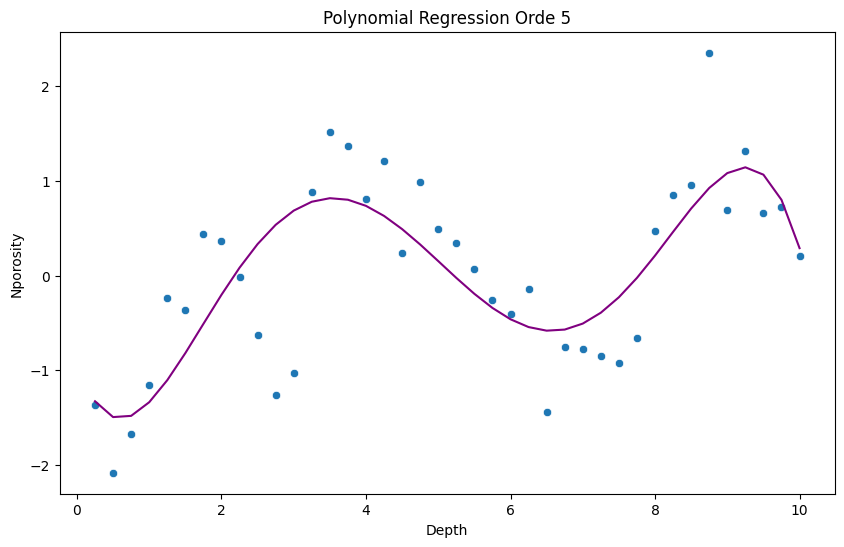

In [78]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Depth', y='Nporosity', data=data)

plt.plot(X, y_pred5, color='purple')

plt.title('Polynomial Regression Orde 5')
plt.xlabel('Depth')
plt.ylabel('Nporosity')

plt.show()

Grafik di atas menunjukkan hasil regresi polynomial orde 5 antara Depth dan Nporosity. Titik-titik pada grafik merupakan data asli, sedangkan garis ungu menunjukkan kurva regresi polynomial orde 5 yang dihasilkan oleh model.

Kurva pada regresi polynomial orde 5 terlihat lebih kompleks dan fleksibel dibandingkan model orde sebelumnya karena model mempertimbangkan fitur hingga Depth⁵. Hal ini memungkinkan model mengikuti pola naik dan turun pada data dengan lebih detail sehingga hubungan antara Depth dan Nporosity dapat dimodelkan dengan lebih baik.

Namun, model dengan orde yang terlalu tinggi juga berpotensi mengalami overfitting, yaitu model terlalu menyesuaikan diri dengan data yang ada sehingga dapat mengurangi kemampuan model dalam melakukan prediksi pada data baru.

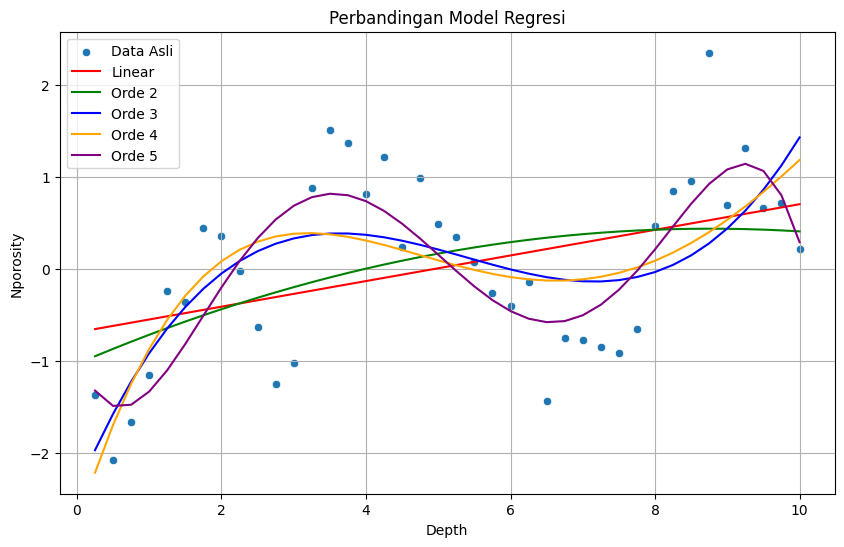

In [79]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')

plt.plot(X, y_pred, color='red', label='Linear')
plt.plot(X, y_pred2, color='green', label='Orde 2')
plt.plot(X, y_pred3, color='blue', label='Orde 3')
plt.plot(X, y_pred4, color='orange', label='Orde 4')
plt.plot(X, y_pred5, color='purple', label='Orde 5')

plt.title("Perbandingan Model Regresi")
plt.xlabel("Depth")
plt.ylabel("Nporosity")

plt.legend()
plt.grid(True)

plt.show()

Grafik di atas menunjukkan perbandingan beberapa model regresi antara Depth dan Nporosity, yaitu regresi linear dan regresi polynomial dengan orde 2, 3, 4, dan 5. Titik-titik biru menunjukkan data asli, sedangkan garis berwarna menunjukkan hasil prediksi dari masing-masing model regresi.

Garis merah menunjukkan regresi linear, yang hanya membentuk garis lurus sehingga tidak mampu mengikuti pola perubahan data secara detail. Hal ini menunjukkan bahwa hubungan antara Depth dan Nporosity kemungkinan tidak sepenuhnya linear.

Model regresi polynomial orde 2 dan orde 3 mulai menunjukkan kurva yang lebih fleksibel sehingga dapat mengikuti pola data dengan lebih baik dibandingkan regresi linear. Kurva tersebut mampu menangkap perubahan naik dan turun pada data Nporosity.

Sementara itu, regresi polynomial orde 4 dan orde 5 menghasilkan kurva yang lebih kompleks dan mampu mengikuti pola data dengan lebih detail. Namun, model dengan orde yang terlalu tinggi berpotensi mengalami overfitting, yaitu model terlalu menyesuaikan diri dengan data yang ada sehingga kurang baik dalam melakukan prediksi pada data baru.

Secara umum, grafik ini menunjukkan bahwa penggunaan regresi polynomial dapat memberikan pemodelan yang lebih baik terhadap hubungan Depth dan Nporosity dibandingkan regresi linear sederhana.